<a href="https://colab.research.google.com/github/Destinywaya9/Wilson-Middleware/blob/main/Wilson_v0_1_1rc3_ECHOP2_LIVE_EARNED_TRUST_AUDIT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Destinywaya9/Wilson-Middleware/blob/main/Wilson_v0_1_1rc3_ECHOP2_LIVE_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wilson v0.1.1rc3 — EchoP2 Closure + External Model + Live Audit

Author/owner: Destiny Machwaya

Runtime only:

`EchoP2 -> entropy/coherence measurement -> model attach -> live user input -> model candidate -> fresh EchoP2/noise audit -> release -> repeat`

Canonical Tensor P2:

`3,3 / 0,0 / 0,1 / 1,2 / 2,1 / 1,0 / 0,0 / Delay(200)`

This notebook uses the exact supplied EchoP2 demonstration circuit with depolarizing noise `p=0.1` and `131072` shots. QRTM, Tensor P3, ethics gates, Pauli tomography, and other extended layers are not in this runtime path.


In [3]:
# 1) Install the rc3 wheel and live-demo dependencies.
import subprocess, sys
from pathlib import Path

WHEEL_NAME = "wilson_open_middleware-0.1.1rc3-py3-none-any.whl"
wheel = Path("/content") / WHEEL_NAME

if not wheel.exists():
    try:
        from google.colab import files
        print(f"Upload {WHEEL_NAME}")
        uploaded = files.upload()
        if WHEEL_NAME not in uploaded:
            matches = [name for name in uploaded if name.endswith('.whl')]
            if not matches:
                raise RuntimeError("No Wilson wheel was uploaded.")
            wheel = Path('/content') / matches[0]
    except ImportError:
        wheel = Path(WHEEL_NAME)

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', str(wheel)], check=True)
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'qiskit>=2.0,<3',
    'qiskit-aer>=0.17,<1',
    'transformers>=4.49,<5',
    'accelerate>=1.2',
    'huggingface_hub>=0.28',
    'torch',
    'gradio>=4.44,<7',
    'matplotlib>=3.8'
], check=True)

print('Installed Wilson:', wheel)


Upload wilson_open_middleware-0.1.1rc3-py3-none-any.whl


Saving wilson_open_middleware-0.1.1rc3-py3-none-any.whl to wilson_open_middleware-0.1.1rc3-py3-none-any.whl
Installed Wilson: /content/wilson_open_middleware-0.1.1rc3-py3-none-any.whl


In [4]:
# 2) EchoP2 is enforced and measured IMMEDIATELY, before any model is attached.
from pathlib import Path
from wilson_middleware import EchoP2AerEngine, WilsonMiddleware

OUT = Path('/content/wilson_live_audit')
OUT.mkdir(parents=True, exist_ok=True)

P2_ENGINE = EchoP2AerEngine(
    shots=131072,
    depolarizing_probability=0.1,
    output_dir=str(OUT / 'echo_p2_runs'),
)

WILSON = WilsonMiddleware(P2_ENGINE)

initial = WILSON.bootstrap_measurement
print('EchoP2 initial closure complete')
print(f"Entropy Leakage: {initial['entropy_leakage_bits']:.6f} bits")
print(f"Coherence Fidelity: {initial['coherence_fidelity_percent']:.8f}%")
print(f"Dominant State: {initial['dominant_state']}")
print(f"P(000): {initial['expected_closure_probability']:.8%}")
print(f"Noise Source: {initial['noise_source']}")
print(f"Shots: {initial['shots']}")
print('Counts:', initial['counts'])


EchoP2 initial closure complete
Entropy Leakage: 0.000000 bits
Coherence Fidelity: 100.00000000%
Dominant State: 000
P(000): 100.00000000%
Noise Source: AER_DEPOLARIZING_P_0.1
Shots: 131072
Counts: {'000': 131072}


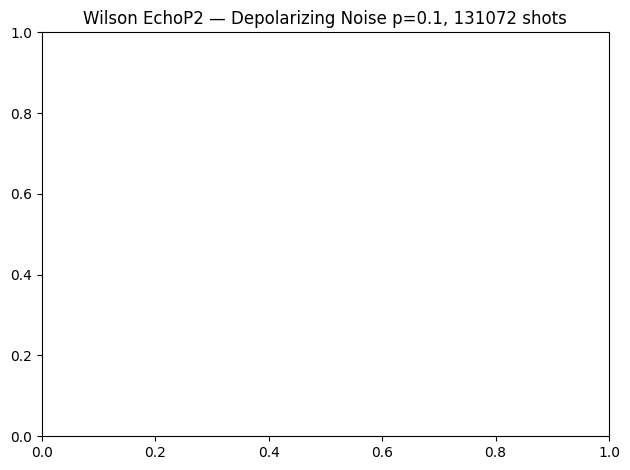

In [5]:
# 3) Visual of the initial measured EchoP2 distribution.
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

plot_histogram(initial['counts'])
plt.title('Wilson EchoP2 — Depolarizing Noise p=0.1, 131072 shots')
plt.tight_layout()
plt.show()


In [6]:
# 4) ONLY AFTER initial P2 closure measurement: attach the external model.
from wilson_middleware.adapters.huggingface import HFTransformersAdapter

MODEL_ID = 'ibm-granite/granite-3.3-2b-instruct'
MODEL_REVISION = 'main'
MAX_NEW_TOKENS = 256

MODEL = HFTransformersAdapter(
    model_id=MODEL_ID,
    revision=MODEL_REVISION,
    max_new_tokens=MAX_NEW_TOKENS,
)

connection = WILSON.attach_model(MODEL)
print('External model connected after EchoP2 measurement:')
print(connection)


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/67.1M [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

External model connected after EchoP2 measurement:
{'model_connected': True, 'model_id': 'ibm-granite/granite-3.3-2b-instruct', 'model_revision': '707f574c62054322f6b5b04b6d075f0a8f05e0f0', 'model_backend': 'huggingface_transformers', 'p2_environment_generation': 1, 'p2_audit_root': '2bca15d50a8db569e600d9cbc14ca6787cd080aacc4200a294a86e0f13b2972e'}


## Additive earned-trust / ethics audit overlay

This section **does not replace or reimplement the rc3 Wilson runtime above**. The same `WILSON` object, `EchoP2AerEngine`, Granite adapter, bootstrap measurement, `WILSON.interact()` call, P2 audit chain, and interaction chain remain authoritative.

The overlay adds only:

- transparent ethics checkpoints aligned around the existing live interaction path;
- a separate append-only earned-trust audit ledger anchored to Wilson's existing P2 and interaction hashes;
- a public `wilson_audit(decision_id)` call and `LAST_WILSON_RESULT.audit()` object call;
- explicit QRTM provenance handling: this early rc3 demo represents **no QRTM measurement unless an actual provenance record is supplied**. No QRTM signal is inferred or substituted.

The public audit exposes determinative middleware evidence and policy matches, not hidden model reasoning.

In [7]:
# Additive trust/ethics overlay around the EXISTING rc3 WILSON instance.
# No new P2 engine, model, or WilsonMiddleware is created here.
import hashlib
import json
import time
from dataclasses import dataclass
from pathlib import Path


def _canonical_json(value):
    return json.dumps(value, sort_keys=True, ensure_ascii=False, separators=(',', ':'), default=str)


def _sha256_text(text):
    return hashlib.sha256(str(text).encode('utf-8')).hexdigest()


def _hash_object(value):
    return _sha256_text(_canonical_json(value))


# Transparent demonstration enforcement map grounded in the public Wilson Open Reference
# License v1.0, Sections 7 and 9. It is deliberately identified as demo enforcement
# scaffolding; it is not represented as an undisclosed/canonical Wilson ethics policy.
ETHICS_POLICY = {
    'policy_id': 'wilson-rc3-public-demo-ethics-overlay-v1',
    'policy_kind': 'transparent-demo-enforcement-map',
    'source': 'Wilson Open Reference License v1.0, Sections 7 and 9',
    'scope_note': (
        'Public demonstration mapping for this early rc3 notebook. '
        'It does not claim to disclose or replace any separate canonical Wilson ethics architecture.'
    ),
    'default_action': 'ALLOW',
    'rules': [
        {
            'rule_id': 'WORL-9A',
            'description': 'Weapons, weapon targeting/control, offensive combat, or systems designed to cause physical harm.',
            'action': 'WITHHOLD',
            'phrases': ['weapon targeting', 'weapon control', 'offensive combat', 'cause physical harm'],
        },
        {
            'rule_id': 'WORL-9B',
            'description': 'Covert surveillance, unlawful monitoring, spyware, or unauthorized tracking.',
            'action': 'WITHHOLD',
            'phrases': ['covert surveillance', 'unlawful monitoring', 'spyware', 'unauthorized tracking'],
        },
        {
            'rule_id': 'WORL-9C',
            'description': 'Coercive behavioral manipulation or exploitative profiling.',
            'action': 'WITHHOLD',
            'phrases': ['coercive behavioral manipulation', 'exploitative profiling'],
        },
        {
            'rule_id': 'WORL-9E',
            'description': 'Malicious interference with systems, networks, scientific records, provenance systems, or audit trails.',
            'action': 'WITHHOLD',
            'phrases': ['malicious interference', 'tamper with audit trail', 'tamper with provenance'],
        },
        {
            'rule_id': 'WORL-9F',
            'description': 'Deliberate falsification of scientific, hardware, QPU, benchmark, or audit evidence.',
            'action': 'WITHHOLD',
            'phrases': ['falsify scientific evidence', 'falsify qpu evidence', 'falsify audit evidence'],
        },
        {
            'rule_id': 'WORL-7-9G',
            'description': 'Do not disable, bypass, conceal, falsify, or remove mandatory Wilson ethics/audit controls.',
            'action': 'WITHHOLD',
            'phrases': ['bypass ethics', 'disable ethics', 'remove audit controls', 'bypass audit', 'disable audit'],
        },
    ],
}
ETHICS_POLICY_SHA256 = _hash_object(ETHICS_POLICY)


def _ethics_checkpoint(text, checkpoint):
    low = str(text or '').lower()
    matched = []
    action = ETHICS_POLICY['default_action']
    for rule in ETHICS_POLICY['rules']:
        hits = [p for p in rule['phrases'] if p.lower() in low]
        if hits:
            matched.append({
                'rule_id': rule['rule_id'],
                'description': rule['description'],
                'action': rule['action'],
                'matched_public_phrases': hits,
            })
            if rule['action'] == 'WITHHOLD':
                action = 'WITHHOLD'
    return {
        'checkpoint': checkpoint,
        'action': action,
        'allowed': action == 'ALLOW',
        'policy_id': ETHICS_POLICY['policy_id'],
        'policy_sha256': ETHICS_POLICY_SHA256,
        'matched_rules': matched,
    }


# This early live rc3 demonstration did not carry a QRTM measurement. Keep that fact
# explicit. A real QRTM provenance record may be attached later without inventing one.
QRTM_PROVENANCE = None


def set_qrtm_provenance(*, measurement_ref, measurement_sha256, source_ref='external'):
    global QRTM_PROVENANCE
    measurement_sha256 = str(measurement_sha256).strip().lower()
    if len(measurement_sha256) != 64 or any(c not in '0123456789abcdef' for c in measurement_sha256):
        raise ValueError('measurement_sha256 must be a 64-character SHA-256 hex digest')
    QRTM_PROVENANCE = {
        'measurement_ref': str(measurement_ref),
        'measurement_sha256': measurement_sha256,
        'source_ref': str(source_ref),
        'inferred': False,
        'substituted': False,
    }
    return dict(QRTM_PROVENANCE)


def _public_qrtm_record():
    if QRTM_PROVENANCE is None:
        return {
            'present': False,
            'inferred': False,
            'substituted': False,
            'note': 'No QRTM measurement is represented in this early rc3 demo.',
        }
    return {'present': True, **dict(QRTM_PROVENANCE)}


TRUST_LEDGER_PATH = OUT / 'Wilson_Earned_Trust_Audit.jsonl'
TRUST_AUDIT_ROWS = []
TRUST_LAST_HASH = 'GENESIS'


def _verify_trust_rows(rows):
    prev = 'GENESIS'
    for index, row in enumerate(rows):
        if row.get('prev_trust_hash') != prev:
            return False, f'chain-link mismatch at index {index}'
        supplied = row.get('trust_hash')
        payload = {k: v for k, v in row.items() if k != 'trust_hash'}
        if _hash_object(payload) != supplied:
            return False, f'trust hash mismatch at index {index}'
        prev = supplied
    return True, 'verified'


def _load_trust_ledger():
    global TRUST_AUDIT_ROWS, TRUST_LAST_HASH
    if not TRUST_LEDGER_PATH.exists() or not TRUST_LEDGER_PATH.stat().st_size:
        return
    rows = [json.loads(line) for line in TRUST_LEDGER_PATH.read_text(encoding='utf-8').splitlines() if line.strip()]
    ok, detail = _verify_trust_rows(rows)
    if not ok:
        raise RuntimeError(f'Existing earned-trust ledger failed verification: {detail}')
    TRUST_AUDIT_ROWS = rows
    TRUST_LAST_HASH = rows[-1]['trust_hash'] if rows else 'GENESIS'


def _append_trust_record(payload):
    global TRUST_LAST_HASH
    row = {
        'audit_schema': 'wilson-rc3-earned-trust-overlay-v1',
        'timestamp_unix': time.time(),
        **dict(payload),
        'prev_trust_hash': TRUST_LAST_HASH,
    }
    row['trust_hash'] = _hash_object(row)
    with TRUST_LEDGER_PATH.open('a', encoding='utf-8') as f:
        f.write(_canonical_json(row) + '\n')
        f.flush()
    TRUST_AUDIT_ROWS.append(row)
    TRUST_LAST_HASH = row['trust_hash']
    return dict(row)


def _redacted_base_evidence(row):
    if not row:
        return None
    # Deliberately exclude request_text and model_output from the public audit.
    keep = [
        'event_id', 'request_id', 'timestamp_unix', 'model_id', 'model_revision', 'model_backend',
        'p2_locked_before_model', 'p2_generation_before_model', 'p2_audit_root_before_model',
        'pre_entropy_leakage_bits', 'pre_coherence_fidelity_percent', 'pre_noise_source',
        'model_candidate_sha256', 'post_p2_closure_complete', 'post_entropy_leakage_bits',
        'post_coherence_fidelity_percent', 'post_noise_source', 'post_counts_json',
        'p2_audit_root_after_model', 'interaction_status', 'response_emitted', 'failure',
        'request_sha256', 'model_output_sha256', 'prev_row_hash', 'row_hash',
    ]
    return {k: row.get(k) for k in keep}


def _why_for(pre_ethics, base_row, terminal_ethics, final_emitted):
    if not pre_ethics['allowed']:
        ids = [r['rule_id'] for r in pre_ethics['matched_rules']]
        return [
            'Release stopped before model execution by the first 0,0 ethics checkpoint.',
            f"Matched public policy rule(s): {', '.join(ids)}.",
        ]
    if not base_row or not base_row.get('response_emitted'):
        return [
            'The existing rc3 Wilson middleware did not authorize release after its fresh EchoP2 closure audit.',
            'The earned-trust layer did not override that base Wilson decision.',
        ]
    if not terminal_ethics['allowed']:
        ids = [r['rule_id'] for r in terminal_ethics['matched_rules']]
        return [
            'The existing rc3 Wilson P2 closure audit authorized the candidate, but the terminal 0,0 ethics checkpoint withheld public release.',
            f"Matched public policy rule(s): {', '.join(ids)}.",
        ]
    if final_emitted:
        return [
            'The existing rc3 P2 environment was locked before model execution.',
            'The original WILSON.interact() path completed its fresh post-model EchoP2 closure audit.',
            'Both transparent ethics checkpoints returned ALLOW.',
            'No audit layer overrode or replaced the underlying Wilson/P2 decision path.',
        ]
    return ['Release was withheld. Inspect the recorded P2 and ethics checkpoint evidence.']


@dataclass
class WilsonAuditedResult:
    decision_id: str
    text: str
    response_emitted: bool
    base_request_id: str | None
    trust_hash: str

    def audit(self):
        return wilson_audit(self.decision_id)

    def verify_audit(self):
        return verify_wilson_audit(self.decision_id)

    def __repr__(self):
        return (
            f"WilsonAuditedResult(decision_id={self.decision_id!r}, "
            f"response_emitted={self.response_emitted}, "
            f"audit_call=\"wilson_audit('{self.decision_id}')\")"
        )


_load_trust_ledger()
LAST_WILSON_RESULT = None


def audited_wilson_interact(prompt):
    """Additive wrapper: ethics/audit around the existing rc3 WILSON.interact()."""
    global LAST_WILSON_RESULT
    prompt = str(prompt or '').strip()
    if not prompt:
        raise ValueError('live user input is empty')

    decision_id = f"trust-{len(TRUST_AUDIT_ROWS):06d}"
    p2_root_at_start = WILSON.audit_chain.last_hash
    interaction_root_at_start = WILSON.interaction_chain.last_hash

    # First canonical 0,0 aligned ethics checkpoint: before external model execution.
    first_ethics = _ethics_checkpoint(prompt, '0,0:first-reference/pre-model')

    base_row = None
    if first_ethics['allowed']:
        # IMPORTANT: this is the original rc3 execution path. It is not reimplemented.
        base_row = WILSON.interact(prompt)

    # Terminal canonical 0,0 aligned ethics checkpoint: after rc3 fresh P2 closure,
    # before the candidate is displayed by this notebook UI.
    if base_row is None:
        terminal_ethics = {
            'checkpoint': '0,0:terminal-closure/pre-display',
            'action': 'WITHHOLD',
            'allowed': False,
            'policy_id': ETHICS_POLICY['policy_id'],
            'policy_sha256': ETHICS_POLICY_SHA256,
            'matched_rules': [],
            'note': 'Not evaluated against model output because the first ethics checkpoint prevented model execution.',
        }
    elif not base_row.get('response_emitted'):
        terminal_ethics = {
            'checkpoint': '0,0:terminal-closure/pre-display',
            'action': 'WITHHOLD',
            'allowed': False,
            'policy_id': ETHICS_POLICY['policy_id'],
            'policy_sha256': ETHICS_POLICY_SHA256,
            'matched_rules': [],
            'note': 'Base rc3 P2 closure already withheld release; the overlay cannot override it.',
        }
    else:
        terminal_ethics = _ethics_checkpoint(base_row.get('model_output', ''), '0,0:terminal-closure/pre-display')

    base_p2_allows = bool(base_row and base_row.get('response_emitted'))
    final_emitted = bool(first_ethics['allowed'] and base_p2_allows and terminal_ethics['allowed'])

    if final_emitted:
        final_text = base_row['model_output']
        final_status = 'EMITTED_AFTER_EXISTING_RC3_P2_AND_ETHICS'
    elif not first_ethics['allowed']:
        final_text = '[WITHHELD: FIRST 0,0 ETHICS CHECKPOINT]'
        final_status = 'WITHHELD_FIRST_0_0_ETHICS'
    elif not base_p2_allows:
        final_text = '[WITHHELD: P2 CLOSURE AUDIT FAILED]'
        final_status = 'WITHHELD_BY_EXISTING_RC3_P2'
    else:
        final_text = '[WITHHELD: TERMINAL 0,0 ETHICS CHECKPOINT]'
        final_status = 'WITHHELD_TERMINAL_0_0_ETHICS'

    base_chain_ok = WILSON.verify_chain()
    p2_chain_ok = WILSON.verify_audit_chain()
    kernel_ok = WILSON.verify_kernel()

    trust_record = _append_trust_record({
        'decision_id': decision_id,
        'final_status': final_status,
        'final_response_emitted': final_emitted,
        'policy_manifest': ETHICS_POLICY,
        'policy_sha256': ETHICS_POLICY_SHA256,
        'ethics_first_0_0': first_ethics,
        'ethics_terminal_0_0': terminal_ethics,
        'qrtm_provenance': _public_qrtm_record(),
        'base_wilson_interaction': _redacted_base_evidence(base_row),
        'base_request_id': base_row.get('request_id') if base_row else None,
        'p2_audit_root_at_start': p2_root_at_start,
        'interaction_root_at_start': interaction_root_at_start,
        'p2_audit_root_after_decision': WILSON.audit_chain.last_hash,
        'interaction_root_after_decision': WILSON.interaction_chain.last_hash,
        'base_kernel_verified': kernel_ok,
        'base_p2_audit_chain_verified': p2_chain_ok,
        'base_interaction_chain_verified': base_chain_ok,
        'why': _why_for(first_ethics, base_row, terminal_ethics, final_emitted),
        'privacy': {
            'request_plaintext_in_public_audit': False,
            'model_output_plaintext_in_public_audit': False,
            'hidden_model_reasoning_recorded': False,
            'note': 'Public audit records decision evidence and hashes, not hidden model chain-of-thought.',
        },
    })

    LAST_WILSON_RESULT = WilsonAuditedResult(
        decision_id=decision_id,
        text=final_text,
        response_emitted=final_emitted,
        base_request_id=base_row.get('request_id') if base_row else None,
        trust_hash=trust_record['trust_hash'],
    )
    return LAST_WILSON_RESULT


def wilson_audit(decision_id):
    matches = [dict(r) for r in TRUST_AUDIT_ROWS if r.get('decision_id') == str(decision_id)]
    if not matches:
        raise KeyError(f'Unknown decision_id: {decision_id}')
    record = matches[-1]
    ok_record = _hash_object({k: v for k, v in record.items() if k != 'trust_hash'}) == record.get('trust_hash')
    chain_ok, chain_detail = _verify_trust_rows(TRUST_AUDIT_ROWS)
    return {
        'decision_id': decision_id,
        'record': record,
        'verification': {
            'this_record_hash_valid': ok_record,
            'earned_trust_chain_valid': chain_ok,
            'earned_trust_chain_detail': chain_detail,
            'current_base_kernel_valid': WILSON.verify_kernel(),
            'current_base_p2_audit_chain_valid': WILSON.verify_audit_chain(),
            'current_base_interaction_chain_valid': WILSON.verify_chain(),
            'policy_hash_matches_manifest': _hash_object(record['policy_manifest']) == record['policy_sha256'],
        },
        'audit_scope': 'Transparent middleware decision evidence; no hidden model chain-of-thought.',
    }


def verify_wilson_audit(decision_id):
    bundle = wilson_audit(decision_id)
    v = bundle['verification']
    ok = all([
        v['this_record_hash_valid'],
        v['earned_trust_chain_valid'],
        v['current_base_kernel_valid'],
        v['current_base_p2_audit_chain_valid'],
        v['current_base_interaction_chain_valid'],
        v['policy_hash_matches_manifest'],
    ])
    return ok, ('verified' if ok else json.dumps(v, sort_keys=True))


print('Earned-trust overlay ready on existing WILSON instance.')
print('Ethics policy:', ETHICS_POLICY['policy_id'])
print('Policy SHA-256:', ETHICS_POLICY_SHA256)
print('QRTM represented in this early demo:', QRTM_PROVENANCE is not None)
print('Base WILSON object preserved:', type(WILSON).__name__)


Earned-trust overlay ready on existing WILSON instance.
Ethics policy: wilson-rc3-public-demo-ethics-overlay-v1
Policy SHA-256: 0a811b94ac98c9d500c22636b1bc18b1eef9557ca290ff58811250219769ef93
QRTM represented in this early demo: False
Base WILSON object preserved: WilsonMiddleware


In [8]:
# 5) EXISTING live rc3 execution + additive earned-trust audit around it.
# The underlying model/P2 execution still occurs through WILSON.interact().
import csv
import json
import gradio as gr


def write_csv(path, rows):
    rows = list(rows)
    if not rows:
        return
    with open(path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)


def persist_live_ledgers():
    # Original rc3 ledgers are preserved exactly.
    write_csv(OUT / 'Wilson_Middleware_Execution_Ledger.csv', WILSON.rows)
    write_csv(OUT / 'Wilson_P2_Live_Audit_Ledger.csv', WILSON.audit_rows)
    (OUT / 'Wilson_Live_Status.json').write_text(
        json.dumps(WILSON.live_status(), indent=2, ensure_ascii=False, default=str),
        encoding='utf-8'
    )
    # Additive earned-trust ledger already persists append-only JSONL on each decision.


def live_submit(prompt):
    prompt = str(prompt or '').strip()
    if not prompt:
        return '', 'Enter a live prompt.', '', ''

    # Additive wrapper. Inside it, allowed prompts execute the original WILSON.interact(prompt).
    result = audited_wilson_interact(prompt)
    status = WILSON.live_status()
    persist_live_ledgers()

    audit = (
        'WILSON LIVE P2 AUDIT\n\n'
        f"P2 Environment Locked: {status['p2_environment_locked']}\n"
        f"Environment Generation: {status['environment_generation']}\n"
        f"Model: {status['model_id']}\n"
        f"Backend: {status['backend_name']}\n"
        f"Noise Source: {status['noise_source']}\n"
        f"Depolarizing p: {status['depolarizing_probability']}\n"
        f"Shots: {status['shots']}\n\n"
        f"Entropy Leakage: {status['entropy_leakage_bits']:.6f} bits\n"
        f"Coherence Fidelity: {status['coherence_fidelity_percent']:.8f}%\n"
        f"Dominant State: {status['dominant_state']}\n"
        f"P(000): {status['expected_closure_probability']:.8%}\n\n"
        f"Counts: {status['counts']}\n\n"
        f"P2 Audit Root: {status['p2_audit_root']}\n"
        f"Interaction Root: {status['interaction_root']}"
    )

    audit_ref = (
        f"Decision ID: {result.decision_id}\n"
        f"Base request ID: {result.base_request_id}\n"
        f"Earned-trust hash: {result.trust_hash}\n\n"
        f"Notebook audit call: wilson_audit('{result.decision_id}')\n"
        f"Last-result audit call: LAST_WILSON_RESULT.audit()\n"
        f"Verification call: LAST_WILSON_RESULT.verify_audit()"
    )
    return result.text, audit, result.decision_id, audit_ref


def audit_decision_ui(decision_id):
    decision_id = str(decision_id or '').strip()
    if not decision_id:
        return 'No decision ID is available yet.'
    try:
        return json.dumps(wilson_audit(decision_id), indent=2, ensure_ascii=False, default=str)
    except Exception as exc:
        return f'Audit lookup failed: {type(exc).__name__}: {exc}'


with gr.Blocks(title='Wilson — EchoP2 Live External Model Test') as demo:
    gr.Markdown(
        '# Wilson — Live External Model Test\n\n'
        '**Existing EchoP2 closure + entropy/coherence measurement + active noise audit, '
        'with additive transparent ethics / earned-trust inspection**\n\n'
        'The rc3 Wilson execution path is unchanged underneath: the external model remains attached '
        'to the existing measured P2 environment and `WILSON.interact()` performs the fresh EchoP2 '
        'closure audit. The added trust layer can withhold display but cannot override a Wilson/P2 withhold.'
    )

    prompt = gr.Textbox(
        label='Live user input',
        placeholder='Type a live prompt...',
        lines=3,
    )
    send = gr.Button('Send to external model')
    response = gr.Textbox(label='External model response', lines=12, interactive=False)
    audit = gr.Textbox(label='Wilson live P2 audit', lines=20, interactive=False)
    decision_id = gr.Textbox(label='Decision / audit ID', interactive=False)
    audit_ref = gr.Textbox(label='Earned-trust audit call', lines=6, interactive=False)
    inspect = gr.Button('Audit this decision')
    public_audit = gr.Textbox(label='Transparent public decision audit', lines=28, interactive=False)

    send.click(live_submit, inputs=prompt, outputs=[response, audit, decision_id, audit_ref])
    prompt.submit(live_submit, inputs=prompt, outputs=[response, audit, decision_id, audit_ref])
    inspect.click(audit_decision_ui, inputs=decision_id, outputs=public_audit)

demo.launch(debug=False)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e116da220e06fd5113.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [9]:
# 6) Final in-session integrity check and current audit state.
import json

persist_live_ledgers()
print('Canonical P2 sequence exact:', WILSON.verify_kernel())
print('P2 audit hash chain valid:', WILSON.verify_audit_chain())
print('Interaction hash chain valid:', WILSON.verify_chain())
print(json.dumps(WILSON.live_status(), indent=2, ensure_ascii=False, default=str))
print('Audit files:', OUT)


Canonical P2 sequence exact: True
P2 audit hash chain valid: True
Interaction hash chain valid: True
{
  "p2_environment_locked": true,
  "environment_generation": 2,
  "model_connected": true,
  "model_id": "ibm-granite/granite-3.3-2b-instruct",
  "backend_name": "aer_simulator",
  "job_id": "722f3f85-4611-4f85-83f2-479f731c3303",
  "noise_source": "AER_DEPOLARIZING_P_0.1",
  "noise_stream_kind": "depolarizing",
  "depolarizing_probability": 0.1,
  "shots": 131072,
  "entropy_leakage_bits": 0.0,
  "coherence_fidelity_percent": 100.0,
  "expected_closure_probability": 1.0,
  "dominant_state": "000",
  "counts": {
    "000": 131072
  },
  "p2_audit_root": "c326234d305b9af81af36ab91550a1e1a4ac0bcfcd39ef29d4b0efb4542ed2a9",
  "interaction_root": "871f7e48b655e1d1268816924afe2cedb38571d8981d995e266d4451ba5c01d7"
}
Audit files: /content/wilson_live_audit


In [10]:
# 7) Additive earned-trust integrity state.
# This does not replace the original final rc3 integrity checks above.
trust_ok, trust_detail = _verify_trust_rows(TRUST_AUDIT_ROWS)
print('Earned-trust audit hash chain valid:', trust_ok, '-', trust_detail)
print('Earned-trust decisions:', len(TRUST_AUDIT_ROWS))
print('Ethics policy ID:', ETHICS_POLICY['policy_id'])
print('Ethics policy SHA-256:', ETHICS_POLICY_SHA256)
print('QRTM represented:', QRTM_PROVENANCE is not None)
print('Earned-trust ledger:', TRUST_LEDGER_PATH)
if LAST_WILSON_RESULT is not None:
    print('Last decision:', LAST_WILSON_RESULT)
    print('Last decision verification:', LAST_WILSON_RESULT.verify_audit())


Earned-trust audit hash chain valid: True - verified
Earned-trust decisions: 1
Ethics policy ID: wilson-rc3-public-demo-ethics-overlay-v1
Ethics policy SHA-256: 0a811b94ac98c9d500c22636b1bc18b1eef9557ca290ff58811250219769ef93
QRTM represented: False
Earned-trust ledger: /content/wilson_live_audit/Wilson_Earned_Trust_Audit.jsonl
Last decision: WilsonAuditedResult(decision_id='trust-000000', response_emitted=True, audit_call="wilson_audit('trust-000000')")
Last decision verification: (True, 'verified')
